In [1]:
import torch
import torchvision
from torch import nn
from torchvision import transforms
from torchinfo import summary
from torchvision import models
from Going_Modular.Data_Setup import create_dataloaders
from Going_Modular.Train import train
from Going_Modular.Test import testing_pipeline
from Going_Modular.Summary_Writer import create_writer
import matplotlib.pyplot as plt

In [2]:
manual_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [3]:
train_dir="pizza_steak_sushi/train"
test_dir="pizza_steak_sushi/test"

In [4]:
train_dataloader,test_dataloader,class_names=create_dataloaders(train_dir,test_dir,manual_transform,manual_transform,8)

In [5]:
image_batch,label_batch=next(iter(train_dataloader))
image,label=image_batch[0],label_batch[0]
image.shape,label

(torch.Size([3, 224, 224]), tensor(2))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

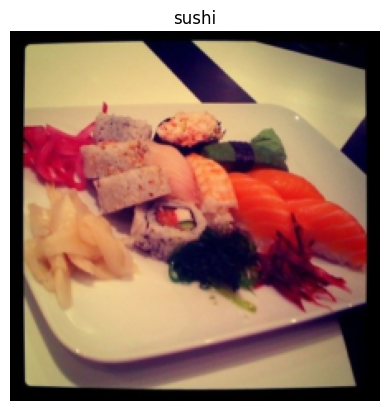

In [6]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off")

In [7]:
height=224
width=224
color_channels=3
patch_size=16
number_of_patches=int((height*width)/patch_size**2)
print(f"Number of patches (N) with image height (H={height}), width (W={width}) and patch size (P={patch_size}): {number_of_patches}")

Number of patches (N) with image height (H=224), width (W=224) and patch size (P=16): 196


In [8]:
embedding_layer_input_shape=(height,width,color_channels)
embedding_layer_output_shape=(number_of_patches,patch_size**2*color_channels)
print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

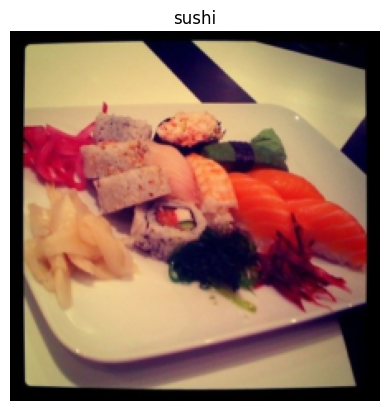

In [9]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off")

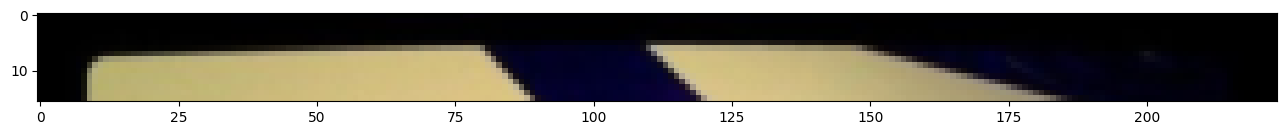

In [10]:
image_permuted=image.permute(1,2,0)
patch_size=16
plt.figure(figsize=(patch_size,patch_size))
plt.imshow(image_permuted[:patch_size,:,:])

Number of patches per row:14.0
Patch size:16 pixels x 16 pixels


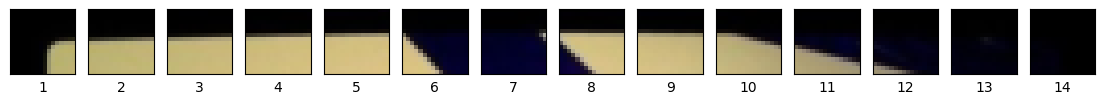

In [11]:
img_size=224
patch_size=16
num_patches=img_size/patch_size
assert img_size%patch_size==0,"Image size must be divisible by patch size"
print(f"Number of patches per row:{num_patches}\nPatch size:{patch_size} pixels x {patch_size} pixels")

fig, axs = plt.subplots(nrows=1,
                        ncols=img_size//patch_size,
                        figsize=(num_patches,num_patches),
                        sharex=True,
                        sharey=True)

for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size,patch:patch+patch_size,:])
    axs[i].set_xlabel(i+1)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Number of patches per row:14.0        
Number of patches per column:14.0        
Total patches:196.0        
Patch size:16 pixels x 16 pixels


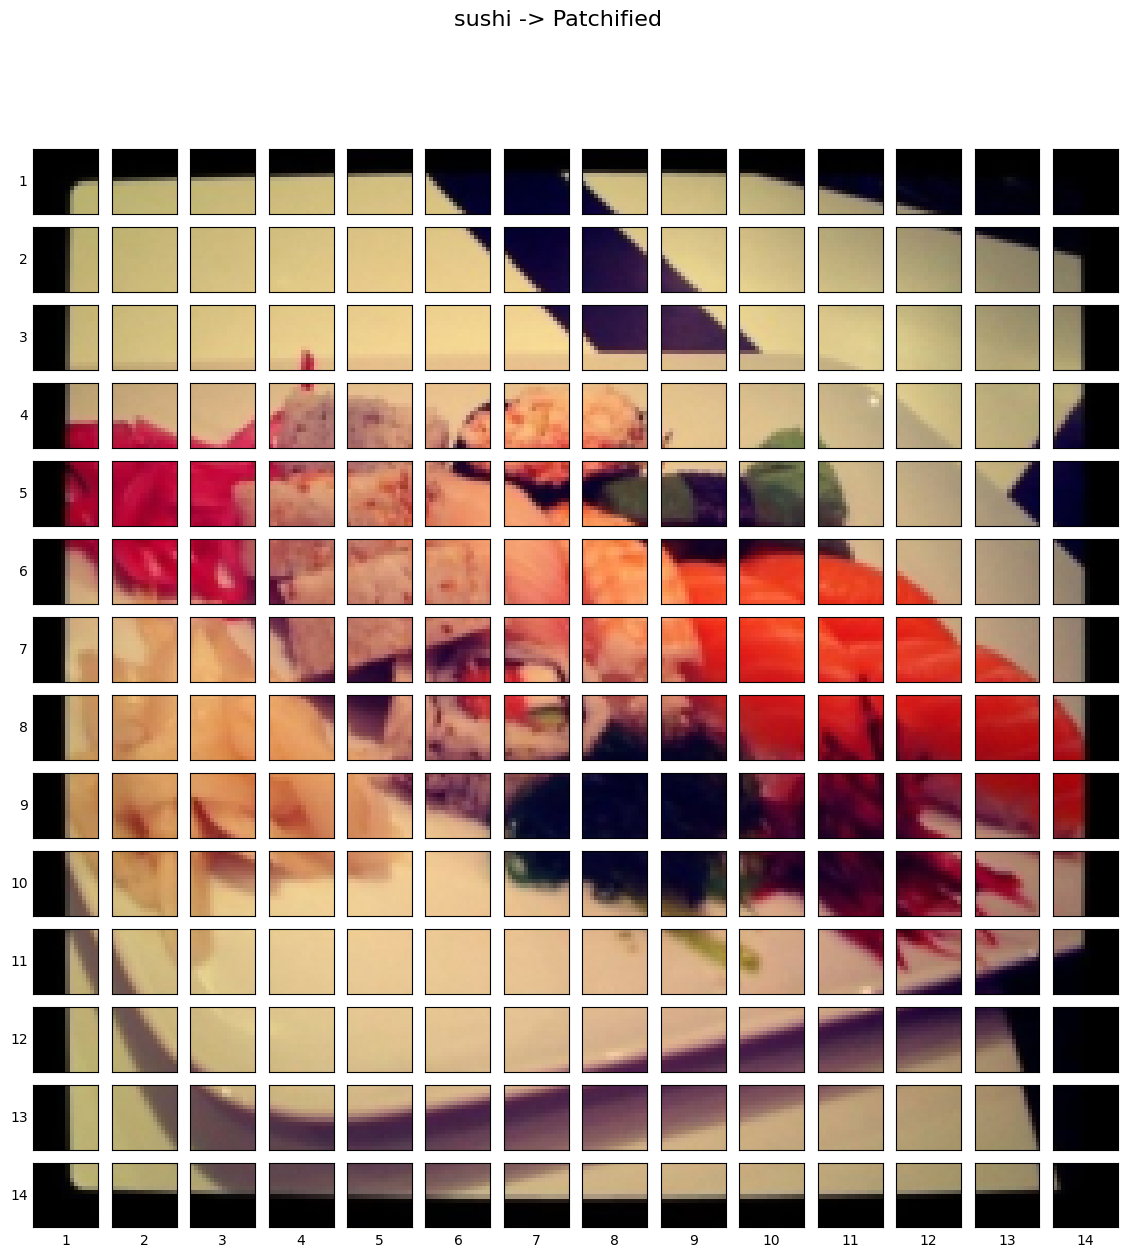

In [12]:
img_size=224
patch_size=16
num_patches=img_size/patch_size
print(f"Number of patches per row:{num_patches}\
        \nNumber of patches per column:{num_patches}\
        \nTotal patches:{num_patches*num_patches}\
        \nPatch size:{patch_size} pixels x {patch_size} pixels")

fig,axs=plt.subplots(nrows=img_size//patch_size,
                        ncols=img_size//patch_size,
                        figsize=(num_patches,num_patches),
                        sharex=True,
                        sharey=True)

for i,patch_height in enumerate(range(0, img_size, patch_size)):
    for j,patch_width in enumerate(range(0, img_size, patch_size)):

        axs[i,j].imshow(image_permuted[patch_height:patch_height+patch_size,
                                        patch_width:patch_width+patch_size,
                                        :])
        
        axs[i,j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i,j].set_xlabel(j+1)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].label_outer()
        
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

In [13]:
conv2d=nn.Conv2d(in_channels=3,
                   out_channels=768,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

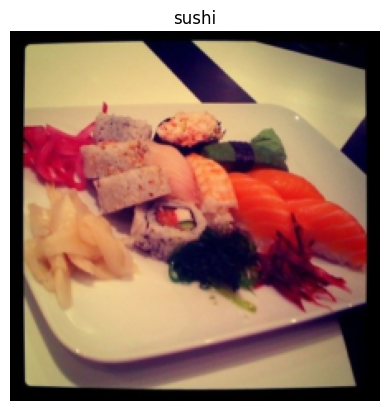

In [14]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off")

In [15]:
image_out_of_conv=conv2d(image.unsqueeze(0))
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


In [16]:
single_feature_map=image_out_of_conv[:,0,:,:]
single_feature_map,single_feature_map.requires_grad

(tensor([[[ 0.0223, -0.0924, -0.0941, -0.1159, -0.1660,  0.0981,  0.0439,
           -0.3403, -0.2055, -0.1911,  0.0279,  0.0835,  0.0247,  0.0335],
          [-0.1113, -0.4837, -0.5092, -0.5255, -0.5426, -0.4428,  0.1096,
           -0.0587, -0.6376, -0.5112, -0.4530, -0.3805, -0.2469, -0.0346],
          [-0.1060, -0.5192, -0.5380, -0.5519, -0.5771, -0.5909, -0.5270,
            0.0038, -0.1541, -0.5178, -0.5640, -0.5013, -0.4137, -0.1729],
          [-0.0448, -0.3975, -0.5027, -0.4971, -0.4153, -0.5590, -0.4396,
           -0.5531, -0.5498, -0.5025, -0.5032, -0.4983, -0.4517, -0.1462],
          [-0.0049, -0.1584, -0.1850, -0.3497, -0.4035, -0.3426, -0.2351,
           -0.1127, -0.2563, -0.2134, -0.4430, -0.4469, -0.4669,  0.0235],
          [-0.0630, -0.2151, -0.3011, -0.3561, -0.4141, -0.4566, -0.4966,
           -0.5211, -0.2091, -0.1429, -0.2484, -0.4801, -0.4043, -0.1718],
          [-0.1384, -0.5132, -0.4508, -0.2522, -0.4118, -0.1385, -0.3300,
           -0.3937, -0.4030, -0.

In [17]:
flatten=nn.Flatten(start_dim=2,end_dim=3)

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


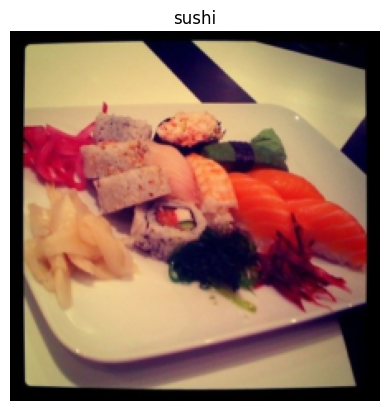

In [18]:
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [19]:
image_out_of_conv_flattened_reshaped=image_out_of_conv_flattened.permute(0, 2, 1)
print(f"Patch embedding sequence shape:{image_out_of_conv_flattened_reshaped.shape}->[batch_size, num_patches, embedding_size]")

Patch embedding sequence shape:torch.Size([1, 196, 768])->[batch_size, num_patches, embedding_size]


(np.float64(-0.5), np.float64(195.5), np.float64(0.5), np.float64(-0.5))

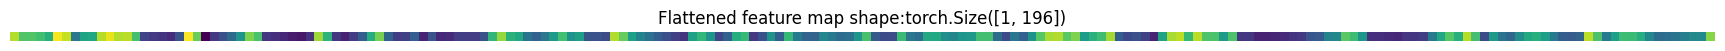

In [20]:
single_flattened_feature_map=image_out_of_conv_flattened_reshaped[:,:,0]

plt.figure(figsize=(22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape:{single_flattened_feature_map.shape}")
plt.axis(False)

In [21]:
single_flattened_feature_map, single_flattened_feature_map.requires_grad, single_flattened_feature_map.shape

(tensor([[ 0.0223, -0.0924, -0.0941, -0.1159, -0.1660,  0.0981,  0.0439, -0.3403,
          -0.2055, -0.1911,  0.0279,  0.0835,  0.0247,  0.0335, -0.1113, -0.4837,
          -0.5092, -0.5255, -0.5426, -0.4428,  0.1096, -0.0587, -0.6376, -0.5112,
          -0.4530, -0.3805, -0.2469, -0.0346, -0.1060, -0.5192, -0.5380, -0.5519,
          -0.5771, -0.5909, -0.5270,  0.0038, -0.1541, -0.5178, -0.5640, -0.5013,
          -0.4137, -0.1729, -0.0448, -0.3975, -0.5027, -0.4971, -0.4153, -0.5590,
          -0.4396, -0.5531, -0.5498, -0.5025, -0.5032, -0.4983, -0.4517, -0.1462,
          -0.0049, -0.1584, -0.1850, -0.3497, -0.4035, -0.3426, -0.2351, -0.1127,
          -0.2563, -0.2134, -0.4430, -0.4469, -0.4669,  0.0235, -0.0630, -0.2151,
          -0.3011, -0.3561, -0.4141, -0.4566, -0.4966, -0.5211, -0.2091, -0.1429,
          -0.2484, -0.4801, -0.4043, -0.1718, -0.1384, -0.5132, -0.4508, -0.2522,
          -0.4118, -0.1385, -0.3300, -0.3937, -0.4030, -0.2961, -0.3321, -0.3731,
          -0.355

In [22]:
class PatchEmbedding(nn.Module):

    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()

        self.patcher=nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        self.flatten=nn.Flatten(start_dim=2,
                                  end_dim=3)

    def forward(self,x):
        x_patched=self.patcher(x)
        x_flattened=self.flatten(x_patched)
        return x_flattened.permute(0,2,1) 

In [23]:
patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

print(f"Input image shape:{image.unsqueeze(0).shape}")
patch_embedded_image=patchify(image.unsqueeze(0))
print(f"Output patch embedding shape:{patch_embedded_image.shape}")

Input image shape:torch.Size([1, 3, 224, 224])
Output patch embedding shape:torch.Size([1, 196, 768])


In [24]:
random_input_image = (1, 3, 224, 224)

summary(
    PatchEmbedding(),
    input_size=random_input_image
    )

Layer (type:depth-idx)                   Output Shape              Param #
PatchEmbedding                           [1, 196, 768]             --
├─Conv2d: 1-1                            [1, 768, 14, 14]          590,592
├─Flatten: 1-2                           [1, 768, 196]             --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [25]:
print(patch_embedded_image)
print(f"Patch embedding shape: {patch_embedded_image.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 0.4077, -0.0458, -0.0062,  ..., -0.0051,  0.0093, -0.0783],
         [ 0.5668,  0.2552,  0.0473,  ..., -0.1093, -0.0829, -0.0095],
         [ 0.6229,  0.2248,  0.0585,  ..., -0.1629, -0.0917,  0.0381],
         ...,
         [-0.1793,  0.1789, -0.1429,  ..., -0.2556,  0.0219,  0.1172],
         [-0.2098,  0.2062, -0.1202,  ..., -0.1901,  0.0346,  0.0517],
         [ 0.0208, -0.0572, -0.0502,  ...,  0.0281, -0.0169,  0.0538]]],
       grad_fn=<PermuteBackward0>)
Patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [26]:
batch_size=patch_embedded_image.shape[0]
embedding_dimension=patch_embedded_image.shape[-1]

class_token = nn.Parameter(torch.ones(batch_size,1,embedding_dimension))

print(class_token[:,:,:10])

print(f"Class token shape: {class_token.shape}->[batch_size,number_of_tokens,embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768])->[batch_size,number_of_tokens,embedding_dimension]


In [27]:
patch_embedded_image_with_class_embedding=torch.cat((class_token, patch_embedded_image),
                                                      dim=1)

print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [ 0.4077, -0.0458, -0.0062,  ..., -0.0051,  0.0093, -0.0783],
         [ 0.5668,  0.2552,  0.0473,  ..., -0.1093, -0.0829, -0.0095],
         ...,
         [-0.1793,  0.1789, -0.1429,  ..., -0.2556,  0.0219,  0.1172],
         [-0.2098,  0.2062, -0.1202,  ..., -0.1901,  0.0346,  0.0517],
         [ 0.0208, -0.0572, -0.0502,  ...,  0.0281, -0.0169,  0.0538]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [28]:
number_of_patches=int((height*width)/patch_size**2)

embedding_dimension=patch_embedded_image_with_class_embedding.shape[2]

position_embedding=nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True)

print(position_embedding[:,:10,:10])
print(f"Position embedding shape:{position_embedding.shape}->[batch_size,number_of_patches,embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape:torch.Size([1, 197, 768])->[batch_size,number_of_patches,embedding_dimension]


In [29]:
patch_and_position_embedding=patch_embedded_image_with_class_embedding+position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positional embeddings added shape:{patch_and_position_embedding.shape}->[batch_size,number_of_patches,embedding_dimension]")

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [1.4077, 0.9542, 0.9938,  ..., 0.9949, 1.0093, 0.9217],
         [1.5668, 1.2552, 1.0473,  ..., 0.8907, 0.9171, 0.9905],
         ...,
         [0.8207, 1.1789, 0.8571,  ..., 0.7444, 1.0219, 1.1172],
         [0.7902, 1.2062, 0.8798,  ..., 0.8099, 1.0346, 1.0517],
         [1.0208, 0.9428, 0.9498,  ..., 1.0281, 0.9831, 1.0538]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepended and positional embeddings added shape:torch.Size([1, 197, 768])->[batch_size,number_of_patches,embedding_dimension]


In [30]:
patch_size = 16

print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True) # make sure it's learnable
print(f"Class token embedding shape: {class_token.shape}")

patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


In [31]:
class MultiheadSelfAttentionBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768,
                 num_heads:int=12,
                 attn_dropout:float=0):
        super().__init__()
        
        self.layer_norm=nn.LayerNorm(normalized_shape=embedding_dim)

        self.multihead_attn=nn.MultiheadAttention(embed_dim=embedding_dim,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                    batch_first=True)
        
    def forward(self,x):
        x=self.layer_norm(x)
        attn_output, _=self.multihead_attn(query=x,
                                             key=x,
                                             value=x,
                                             need_weights=False)
        return attn_output

In [32]:
multihead_self_attention_block=MultiheadSelfAttentionBlock(embedding_dim=768,
                                                             num_heads=12)

patched_image_through_msa_block=multihead_self_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape MSA block: {patched_image_through_msa_block.shape}")

Input shape of MSA block: torch.Size([1, 197, 768])
Output shape MSA block: torch.Size([1, 197, 768])


In [33]:
class MLPBlock(nn.Module):
    
    def __init__(self,
                 embedding_dim:int=768,
                 mlp_size:int=3072,
                 dropout:float=0.1):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size,
                      out_features=embedding_dim),
            nn.Dropout(p=dropout)
        )

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x

In [34]:
mlp_block = MLPBlock(embedding_dim=768, 
                     mlp_size=3072,
                     dropout=0.1)

patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape MLP block: {patched_image_through_mlp_block.shape}")

Input shape of MLP block: torch.Size([1, 197, 768])
Output shape MLP block: torch.Size([1, 197, 768])


In [35]:
class TransformerEncoderBlock(nn.Module):
    
    def __init__(self,
                 embedding_dim:int=768,
                 num_heads:int=12,
                 mlp_size:int=3072,
                 mlp_dropout:float=0.1,
                 attn_dropout:float=0):
        super().__init__()

        self.msa_block=MultiheadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                     num_heads=num_heads,
                                                     attn_dropout=attn_dropout)

        self.mlp_block=MLPBlock(embedding_dim=embedding_dim,
                                   mlp_size=mlp_size,
                                   dropout=mlp_dropout)

    def forward(self,x):

        x=self.msa_block(x)+x

        x=self.mlp_block(x)+x
        
        return x

In [36]:
transformer_encoder_block=TransformerEncoderBlock()

summary(model=transformer_encoder_block,
        input_size=(1, 197, 768))

Layer (type:depth-idx)                   Output Shape              Param #
TransformerEncoderBlock                  [1, 197, 768]             --
├─MultiheadSelfAttentionBlock: 1-1       [1, 197, 768]             --
│    └─LayerNorm: 2-1                    [1, 197, 768]             1,536
│    └─MultiheadAttention: 2-2           [1, 197, 768]             2,362,368
├─MLPBlock: 1-2                          [1, 197, 768]             --
│    └─LayerNorm: 2-3                    [1, 197, 768]             1,536
│    └─Sequential: 2-4                   [1, 197, 768]             --
│    │    └─Linear: 3-1                  [1, 197, 3072]            2,362,368
│    │    └─GELU: 3-2                    [1, 197, 3072]            --
│    │    └─Dropout: 3-3                 [1, 197, 3072]            --
│    │    └─Linear: 3-4                  [1, 197, 768]             2,360,064
│    │    └─Dropout: 3-5                 [1, 197, 768]             --
Total params: 7,087,872
Trainable params: 7,087,872
Non-tr

In [37]:
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768,
                                                             nhead=12,
                                                             dim_feedforward=3072,
                                                             dropout=0.1,
                                                             activation="gelu",
                                                             batch_first=True,
                                                             norm_first=True)
torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [38]:
summary(model=torch_transformer_encoder_layer,
        input_size=(1, 197, 768))

Layer (type:depth-idx)                   Output Shape              Param #
TransformerEncoderLayer                  [1, 197, 768]             --
├─LayerNorm: 1-1                         [1, 197, 768]             1,536
├─MultiheadAttention: 1-2                [1, 197, 768]             2,362,368
├─Dropout: 1-3                           [1, 197, 768]             --
├─LayerNorm: 1-4                         [1, 197, 768]             1,536
├─Linear: 1-5                            [1, 197, 3072]            2,362,368
├─Dropout: 1-6                           [1, 197, 3072]            --
├─Linear: 1-7                            [1, 197, 768]             2,360,064
├─Dropout: 1-8                           [1, 197, 768]             --
Total params: 7,087,872
Trainable params: 7,087,872
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.73
Input size (MB): 0.61
Forward/backward pass size (MB): 8.47
Params size (MB): 18.90
Estimated Total Size (MB): 27.98

In [39]:
class ViT(nn.Module):
    def __init__(self,
                 img_size:int=224,
                 in_channels:int=3,
                 patch_size:int=16,
                 num_transformer_layers:int=12,
                 embedding_dim:int=768,
                 mlp_size:int=3072,
                 num_heads:int=12,
                 attn_dropout:float=0,
                 mlp_dropout:float=0.1,
                 embedding_dropout:float=0.1,
                 num_classes:int=1000):
        super().__init__()

        self.num_patches = (img_size * img_size) // patch_size**2

        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)

        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                               requires_grad=True)

        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)

        self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                            num_heads=num_heads,
                                                                            mlp_size=mlp_size,
                                                                            mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])

        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
        )

    def forward(self, x):

        batch_size = x.shape[0]

        class_token = self.class_embedding.expand(batch_size, -1, -1) 

        x = self.patch_embedding(x)

        x = torch.cat((class_token, x), dim=1)

        x = self.position_embedding + x

        x = self.embedding_dropout(x)
        
        x = self.transformer_encoder(x)

        x = self.classifier(x[:, 0])

        return x

In [40]:
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768))
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1)

print(f"Shape of class token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of class token embedding expanded: {class_token_embedding_expanded.shape}")

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token embedding expanded: torch.Size([32, 1, 768])


In [41]:
random_image_tensor = torch.randn(1, 3, 224, 224)
vit = ViT(num_classes=len(class_names))
vit(random_image_tensor)

tensor([[ 0.4018, -0.3062,  0.0211]], grad_fn=<AddmmBackward0>)

In [42]:
summary(
    model=vit,
    input_size=(32, 3, 224, 224)
)

Layer (type:depth-idx)                             Output Shape              Param #
ViT                                                [32, 3]                   152,064
├─PatchEmbedding: 1-1                              [32, 196, 768]            --
│    └─Conv2d: 2-1                                 [32, 768, 14, 14]         590,592
│    └─Flatten: 2-2                                [32, 768, 196]            --
├─Dropout: 1-2                                     [32, 197, 768]            --
├─Sequential: 1-3                                  [32, 197, 768]            --
│    └─TransformerEncoderBlock: 2-3                [32, 197, 768]            --
│    │    └─MultiheadSelfAttentionBlock: 3-1       [32, 197, 768]            2,363,904
│    │    └─MLPBlock: 3-2                          [32, 197, 768]            4,723,968
│    └─TransformerEncoderBlock: 2-4                [32, 197, 768]            --
│    │    └─MultiheadSelfAttentionBlock: 3-3       [32, 197, 768]            2,363,904
│   

In [45]:
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3,
                             betas=(0.9, 0.999),
                             weight_decay=0.3)

loss_fn = torch.nn.CrossEntropyLoss()

results = train(
    vit,
    train_dataloader,
    test_dataloader,
    optimizer,
    loss_fn,
    1
)

  0%|          | 0/1 [00:00<?, ?it/s]

-----Epoch 1-----
Training loss is 1.237566824617057
Training accuracy is 0.35344827586206895
Time taken for training is 747.1801864000154.


In [46]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT 

pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights)

for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names))

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\KIIT0001/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████| 330M/330M [00:58<00:00, 5.91MB/s]


In [48]:
summary(
    model=pretrained_vit,
    input_size=(32, 3, 224, 224)
)

Layer (type:depth-idx)                        Output Shape              Param #
VisionTransformer                             [32, 3]                   768
├─Conv2d: 1-1                                 [32, 768, 14, 14]         (590,592)
├─Encoder: 1-2                                [32, 197, 768]            151,296
│    └─Dropout: 2-1                           [32, 197, 768]            --
│    └─Sequential: 2-2                        [32, 197, 768]            --
│    │    └─EncoderBlock: 3-1                 [32, 197, 768]            (7,087,872)
│    │    └─EncoderBlock: 3-2                 [32, 197, 768]            (7,087,872)
│    │    └─EncoderBlock: 3-3                 [32, 197, 768]            (7,087,872)
│    │    └─EncoderBlock: 3-4                 [32, 197, 768]            (7,087,872)
│    │    └─EncoderBlock: 3-5                 [32, 197, 768]            (7,087,872)
│    │    └─EncoderBlock: 3-6                 [32, 197, 768]            (7,087,872)
│    │    └─EncoderBlock: 3-

In [49]:
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [53]:
train_dataloader_pretrained, test_dataloader_pretrained, class_names = create_dataloaders(
    train_dir,
    test_dir,
    pretrained_vit_transforms,
    pretrained_vit_transforms,
    8
)

In [56]:
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=0.003)
loss_fn = torch.nn.CrossEntropyLoss()

pretrained_vit_results = train(pretrained_vit,
                                      train_dataloader_pretrained,
                                      test_dataloader_pretrained,
                                      optimizer,
                                      loss_fn,
                                      3)

  0%|          | 0/3 [00:00<?, ?it/s]

-----Epoch 1-----
Training loss is 0.0075667019921419176
Training accuracy is 1.0
-----Epoch 2-----
Training loss is 0.0043536103461018025
Training accuracy is 1.0
-----Epoch 3-----
Training loss is 0.0010552182254192804
Training accuracy is 1.0
Time taken for training is 251.35706470004516.


In [57]:
torch.save(pretrained_vit.state_dict(),"pretrained_vit.pth")